# 04 — Analyse d'erreurs et simulation supply chain

Ce notebook relie la qualité prédictive aux conséquences opérationnelles simulées.


In [4]:
from pathlib import Path
import pandas as pd
import plotly.express as px

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
by_family = pd.read_csv(ROOT / "outputs" / "holdout_metrics_by_family.csv")
by_horizon = pd.read_csv(ROOT / "outputs" / "holdout_metrics_by_horizon.csv")
inventory = pd.read_csv(ROOT / "outputs" / "inventory_comparison.csv")


,family,mae,wape,bias,rmsle,rmse,forecast_accuracy,n
0,BABY CARE,0.168121,0.537986,0.074482,0.147486,0.451520,0.462014,64
3,CLEANING,495.230055,0.243499,0.185621,0.273759,629.099730,0.756501,128
7,HOME CARE,109.962518,0.209082,0.128778,0.232465,149.534394,0.790918,128
6,HOME AND KITCHEN II,12.182620,0.206185,-0.046887,0.261660,26.857393,0.793815,128
8,"LIQUOR,WINE,BEER",27.836335,0.162208,-0.008789,0.276685,42.137520,0.837792,128
1,BEVERAGES,1040.461946,0.151221,0.095781,0.168906,1441.266867,0.848779,128
4,DAIRY,237.341641,0.144841,0.124866,0.166358,309.449020,0.855159,128
11,SEAFOOD,8.076813,0.143190,-0.010238,0.352121,11.556149,0.856810,128
9,PERSONAL CARE,76.350583,0.138289,0.043919,0.191693,103.997829,0.861711,128
5,GROCERY I,1092.643484,0.131604,0.066960,0.159245,1517.812779,0.868396,128


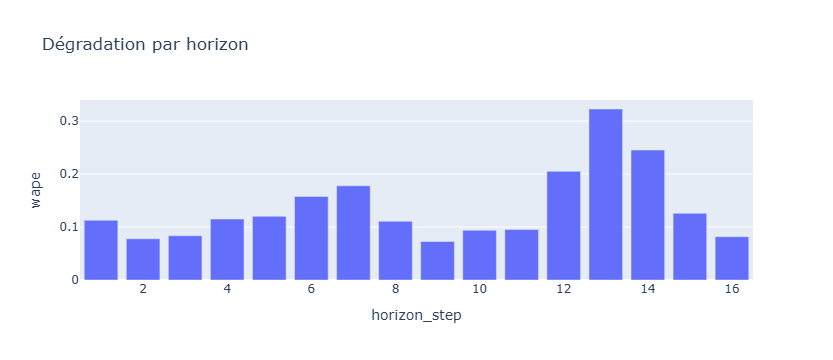

In [5]:
display(by_family.sort_values("wape", ascending=False))
px.bar(by_horizon, x="horizon_step", y="wape", title="Dégradation par horizon")


,policy,demand_units,fulfilled_units,lost_sales_units,holding_cost,stockout_cost,total_cost,orders,fill_rate
0,champion,3250550.785,3.250257e+06,294.120502,407943.872197,588.241004,408532.113201,1049,0.999910
1,seasonal_naive_7,3250550.785,3.249416e+06,1134.552266,339493.824084,2269.104531,341762.928615,1019,0.999651


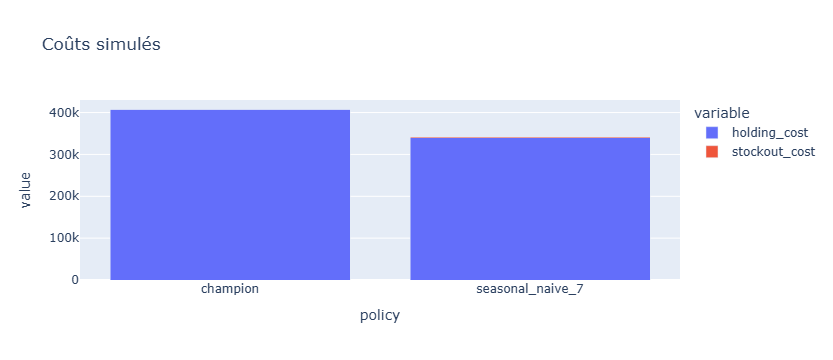

In [6]:
display(inventory)
px.bar(inventory, x="policy", y=["holding_cost", "stockout_cost"], barmode="stack", title="Coûts simulés")


La simulation utilise des paramètres hypothétiques. Elle sert à montrer comment traduire WAPE et biais en décisions de stock, pas à prétendre reproduire l'inventaire réel de Favorita.
